In [4]:
import torch
from sentence_transformers import SentenceTransformer

# step 1: check file exists
import os
print(f"model.pt exists: {os.path.exists('model.pt')}")
print(f"model.pt size: {os.path.getsize('model.pt') / 1e6:.1f} MB")

# step 2: try loading
try:
    sbert_model = torch.load("model.pt", map_location="cpu", weights_only=False)
    print(f"Loaded successfully")
    print(f"Type: {type(sbert_model)}")
    sbert_model.eval()

    # step 3: test it works
    test_scores = sbert_model.encode(["test query"], convert_to_numpy=True)
    print(f"Encoding works — output shape: {test_scores.shape}")
    print("Model is ready to use")

except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")

model.pt exists: True
model.pt size: 92.0 MB
Loaded successfully
Type: <class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>
Encoding works — output shape: (1, 384)
Model is ready to use


Using device: cuda
Filtering queries with 3 or more positive passages...
Found 3136 qualifying queries
Avg passages per query: 10.0
Avg positives per query: 2.2
Sampled 2000 queries for 3-way comparison

Loading Base BERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12067.76it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading SBERT (groupmates' fine-tuned model)...
Groupmates' SBERT loaded — type: <class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>
Loading LexBERT...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10122.98it/s]
[transformers] BertModel LOAD REPORT from: ./bert-wiki-backbone
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Using: lex_bert_marco_final.pt

Running 3-way evaluation on 2000 queries...
────────────────────────────────────────────────────────────
  [100/2000] Base: 0.4522 | SBERT: 0.6022 | LexBERT: 0.6786
  [200/2000] Base: 0.4339 | SBERT: 0.5981 | LexBERT: 0.6774
  [300/2000] Base: 0.4354 | SBERT: 0.6131 | LexBERT: 0.6839
  [400/2000] Base: 0.4216 | SBERT: 0.6107 | LexBERT: 0.6868
  [500/2000] Base: 0.4245 | SBERT: 0.6254 | LexBERT: 0.6991
  [600/2000] Base: 0.4311 | SBERT: 0.6212 | LexBERT: 0.7008
  [700/2000] Base: 0.4354 | SBERT: 0.6282 | LexBERT: 0.6979
  [800/2000] Base: 0.4330 | SBERT: 0.6317 | LexBERT: 0.6975
  [900/2000] Base: 0.4329 | SBERT: 0.6301 | LexBERT: 0.6900
  [1000/2000] Base: 0.4325 | SBERT: 0.6284 | LexBERT: 0.6888
  [1100/2000] Base: 0.4366 | SBERT: 0.6325 | LexBERT: 0.6840
  [1200/2000] Base: 0.4372 | SBERT: 0.6332 | LexBERT: 0.6833
  [1300/2000] Base: 0.4358 | SBERT: 0.6301 | LexBERT: 0.6805
  [1400/2000] Base: 0.4331 | SBERT: 0.6321 | LexBERT: 0.6774
  [1500/2000] Ba

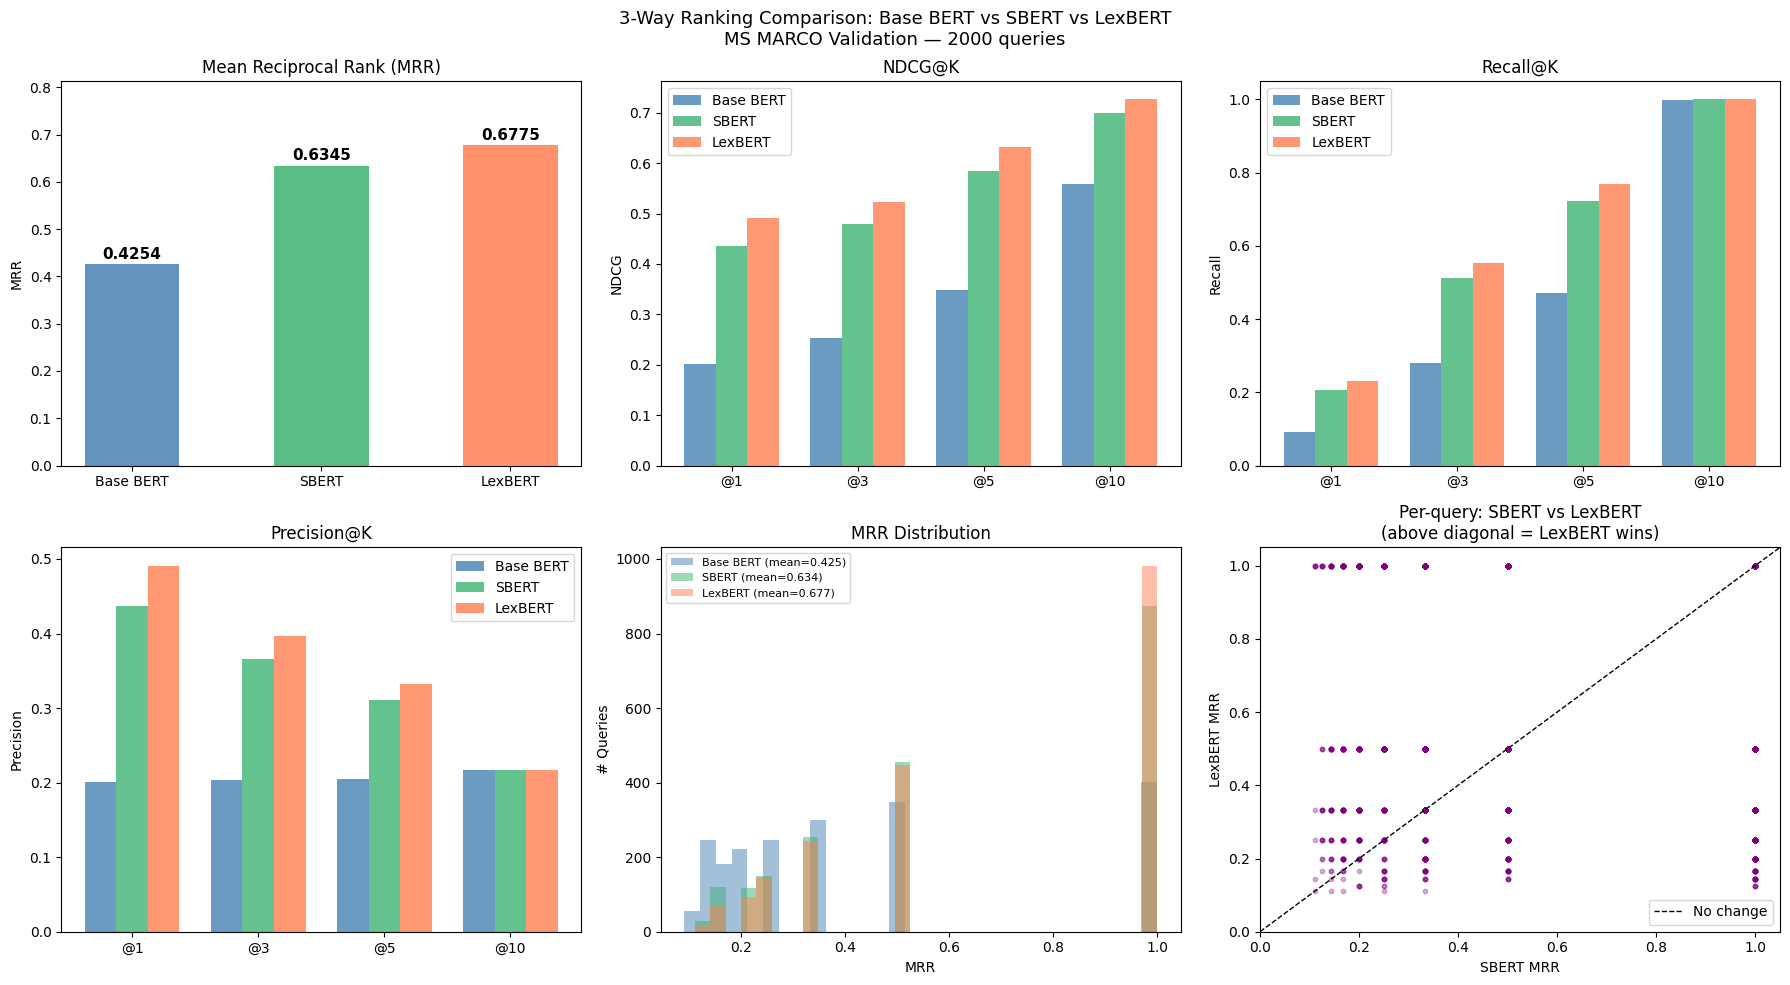


Saved: three_way_comparison.png


In [ ]:
import gc
import os
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
from transformers import BertTokenizer, BertModel
import subprocess
subprocess.run(["pip", "install", "sentence-transformers"], check=True)
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from collections import defaultdict

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Model 1: Base BERT (your untrained baseline) ──────────────────────────────
class BaseBertScorer(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

    def forward(self, q_ids, q_mask, q_type, p_ids, p_mask, p_type):
        q_cls = self.bert(input_ids=q_ids, attention_mask=q_mask,
                          token_type_ids=q_type).last_hidden_state[:, 0, :]
        p_cls = self.bert(input_ids=p_ids, attention_mask=p_mask,
                          token_type_ids=p_type).last_hidden_state[:, 0, :]
        q_cls = torch.nn.functional.normalize(q_cls, dim=-1)
        p_cls = torch.nn.functional.normalize(p_cls, dim=-1)
        return (q_cls * p_cls).sum(dim=-1)

# ── Model 3: LexBERT (your trained model) ────────────────────────────────────
class LexBertRanker(nn.Module):
    def __init__(self, bert_model_name="bert-base-uncased", n_lex_features=5):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden = self.bert.config.hidden_size

        self.lex_projection = nn.Linear(n_lex_features, 64)
        self.relu           = nn.ReLU()
        self.dropout        = nn.Dropout(0.1)
        self.q_proj         = nn.Linear(hidden, 256)
        self.p_proj         = nn.Linear(hidden, 256)
        self.lex_classifier = nn.Linear(256 + 64, 1)

    def encode(self, input_ids, attention_mask, token_type_ids):
        out = self.bert(input_ids=input_ids,
                        attention_mask=attention_mask,
                        token_type_ids=token_type_ids)
        return out.last_hidden_state[:, 0, :]

    def project_query(self, cls_vec):
        return self.q_proj(cls_vec)

    def project_passage(self, cls_vec):
        return self.p_proj(cls_vec)

    def lex_score(self, q_proj, lex_features):
        lex_vec  = self.dropout(self.relu(self.lex_projection(lex_features)))
        combined = torch.cat([q_proj, lex_vec], dim=1)
        return self.lex_classifier(combined).squeeze(-1)

    def forward(self, q_input_ids, q_attention_mask, q_token_type_ids,
                p_input_ids, p_attention_mask, p_token_type_ids, lex_features):
        q_cls  = self.encode(q_input_ids, q_attention_mask, q_token_type_ids)
        p_cls  = self.encode(p_input_ids, p_attention_mask, p_token_type_ids)
        q_proj = torch.nn.functional.normalize(self.project_query(q_cls), dim=-1)
        p_proj = torch.nn.functional.normalize(self.project_passage(p_cls), dim=-1)
        dot    = (q_proj * p_proj).sum(dim=-1)
        lex    = self.lex_score(q_proj, lex_features)
        return dot + lex

# ── lexical features ──────────────────────────────────────────────────────────
def compute_lex_features(query, passage):
    qt = query.lower().split()
    pt = passage.lower().split()
    qs, ps = set(qt), set(pt)
    overlap  = len(qs & ps) / len(qs) if qs else 0.0
    jaccard  = len(qs & ps) / len(qs | ps) if (qs | ps) else 0.0
    try:
        mat = TfidfVectorizer().fit_transform([query, passage])
        tfidf_sim = sklearn_cosine(mat[0], mat[1])[0][0]
    except:
        tfidf_sim = 0.0
    length  = np.log1p(len(pt)) / 10.0
    density = sum(pt.count(t) for t in qt) / max(len(pt), 1)
    return np.array([overlap, jaccard, tfidf_sim, length, density], dtype=np.float32)

# ── scoring functions ─────────────────────────────────────────────────────────
@torch.no_grad()
def score_base_bert(model, tokenizer, query, passages, device):
    scores = []
    for passage in passages:
        qe = tokenizer(query,   max_length=64,  padding="max_length",
                       truncation=True, return_tensors="pt")
        pe = tokenizer(passage, max_length=128, padding="max_length",
                       truncation=True, return_tensors="pt")
        s = model(
            qe["input_ids"].to(device), qe["attention_mask"].to(device),
            qe["token_type_ids"].to(device),
            pe["input_ids"].to(device), pe["attention_mask"].to(device),
            pe["token_type_ids"].to(device),
        )
        scores.append(s.item())
    return scores

def score_sbert(sbert_model, query, passages):
    """Exact same scoring logic as groupmates' evaluate.py"""
    q_emb  = sbert_model.encode([query],   show_progress_bar=False,
                                 convert_to_numpy=True)
    p_embs = sbert_model.encode(passages,  show_progress_bar=False,
                                 convert_to_numpy=True, batch_size=32)
    q      = q_emb.squeeze()
    q_norm = q / (np.linalg.norm(q) + 1e-8)
    p_norm = p_embs / (np.linalg.norm(p_embs, axis=1, keepdims=True) + 1e-8)
    scores = np.dot(p_norm, q_norm)
    return ((scores + 1.0) / 2.0).tolist()   # normalize to [0,1] like they do

@torch.no_grad()
def score_lexbert(model, tokenizer, query, passages, device):
    scores = []
    for passage in passages:
        qe  = tokenizer(query,   max_length=64,  padding="max_length",
                        truncation=True, return_tensors="pt")
        pe  = tokenizer(passage, max_length=128, padding="max_length",
                        truncation=True, return_tensors="pt")
        lex = torch.tensor(compute_lex_features(query, passage)).unsqueeze(0).to(device)
        s   = model(
            qe["input_ids"].to(device), qe["attention_mask"].to(device),
            qe["token_type_ids"].to(device),
            pe["input_ids"].to(device), pe["attention_mask"].to(device),
            pe["token_type_ids"].to(device), lex
        )
        scores.append(s.item())
    return scores

# ── metrics ───────────────────────────────────────────────────────────────────
def mrr(ranked_labels):
    for rank, label in enumerate(ranked_labels, 1):
        if label == 1:
            return 1.0 / rank
    return 0.0

def recall_at_k(ranked_labels, k):
    total = sum(ranked_labels)
    if total == 0: return 0.0
    return sum(ranked_labels[:k]) / total

def ndcg_at_k(ranked_labels, k):
    dcg  = sum(l / np.log2(r + 2) for r, l in enumerate(ranked_labels[:k]))
    idcg = sum(1.0 / np.log2(r + 2) for r in range(min(sum(ranked_labels), k)))
    return dcg / idcg if idcg > 0 else 0.0

def precision_at_k(ranked_labels, k):
    return sum(ranked_labels[:k]) / k

def get_ranked_labels(scores, labels):
    order = np.argsort(scores)[::-1]
    return [labels[i] for i in order]

# ── load data ─────────────────────────────────────────────────────────────────
print("Filtering queries with 3 or more positive passages...")
eval_queries = []
for ex in msmarco:
    texts    = ex["passages"]["passage_text"]
    selected = ex["passages"]["is_selected"]
    if sum(selected) >= 4:  # at least 2 positive passages
        eval_queries.append({
            "query":    ex["query"],
            "passages": texts,
            "labels":   selected,
        })

print(f"Found {len(eval_queries)} qualifying queries")
print(f"Avg passages per query: {np.mean([len(q['passages']) for q in eval_queries]):.1f}")
print(f"Avg positives per query: {np.mean([sum(q['labels']) for q in eval_queries]):.1f}")

# sample from these
import random
random.seed(42)
eval_queries = random.sample(eval_queries, min(2000, len(eval_queries)))
print(f"Sampled {len(eval_queries)} queries for 3-way comparison")


# ── load all three models ─────────────────────────────────────────────────────
print("\nLoading Base BERT...")
base_model = BaseBertScorer().to(device)
base_model.eval()

print("Loading SBERT  fine-tuned model...")
sbert_model = torch.load("model.pt", map_location="cpu", weights_only=False)
sbert_model.eval()
print(f"SBERT loaded — type: {type(sbert_model)}")

print("Loading LexBERT...")
backbone  = "./bert-wiki-backbone" if os.path.exists("./bert-wiki-backbone") else "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(backbone)
lex_model = LexBertRanker(bert_model_name=backbone, n_lex_features=5)
for ckpt in ["lex_bert_marco_final.pt", "lex_bert_marco_best.pt", "lex_bert_nq.pt"]:
    if os.path.exists(ckpt):
        print(f"  Using: {ckpt}")
        lex_model.load_state_dict(torch.load(ckpt, map_location="cpu"))
        lex_ckpt = ckpt
        break
lex_model = lex_model.to(device)
lex_model.eval()

base_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# ── evaluation loop ───────────────────────────────────────────────────────────
K_VALUES = [1, 3, 5, 10]
MODEL_NAMES = ["Base BERT", "SBERT", "LexBERT"]
results  = {m: defaultdict(list) for m in MODEL_NAMES}
per_query = []

print(f"\nRunning 3-way evaluation on {len(eval_queries)} queries...")
print("─" * 60)

for i, ex in enumerate(eval_queries):
    query    = ex["query"]
    passages = ex["passages"]
    labels   = ex["labels"]

    # score with all three models
    base_scores  = score_base_bert(base_model,  base_tokenizer, query, passages, device)
    sbert_scores = score_sbert(sbert_model, query, passages)
    lex_scores   = score_lexbert(lex_model, tokenizer, query, passages, device)

    # rank
    base_ranked  = get_ranked_labels(base_scores,  labels)
    sbert_ranked = get_ranked_labels(sbert_scores, labels)
    lex_ranked   = get_ranked_labels(lex_scores,   labels)

    ranked = {
        "Base BERT": base_ranked,
        "SBERT":     sbert_ranked,
        "LexBERT":   lex_ranked,
    }

    # compute metrics
    for model_name, ranked_labels in ranked.items():
        results[model_name]["mrr"].append(mrr(ranked_labels))
        for k in K_VALUES:
            results[model_name][f"recall@{k}"].append(recall_at_k(ranked_labels, k))
            results[model_name][f"ndcg@{k}"].append(ndcg_at_k(ranked_labels, k))
            results[model_name][f"p@{k}"].append(precision_at_k(ranked_labels, k))

    per_query.append({
        "query":        query,
        "labels":       labels,
        "base_scores":  base_scores,
        "sbert_scores": sbert_scores,
        "lex_scores":   lex_scores,
        "base_mrr":     mrr(base_ranked),
        "sbert_mrr":    mrr(sbert_ranked),
        "lex_mrr":      mrr(lex_ranked),
    })

    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(eval_queries)}] "
              f"Base: {np.mean(results['Base BERT']['mrr']):.4f} | "
              f"SBERT: {np.mean(results['SBERT']['mrr']):.4f} | "
              f"LexBERT: {np.mean(results['LexBERT']['mrr']):.4f}")

# ── results table ─────────────────────────────────────────────────────────────
print("\n" + "═" * 75)
print(f"  3-WAY RESULTS  ({len(eval_queries)} queries)")
print("═" * 75)
print(f"{'Metric':<20} {'Base BERT':>12} {'SBERT':>12} {'LexBERT':>12}")
print("─" * 75)

for m in (["mrr"] +
          [f"ndcg@{k}"   for k in K_VALUES] +
          [f"recall@{k}" for k in K_VALUES] +
          [f"p@{k}"      for k in K_VALUES]):
    bv = np.mean(results["Base BERT"][m])
    sv = np.mean(results["SBERT"][m])
    lv = np.mean(results["LexBERT"][m])
    # bold the best value with an arrow
    best = max(bv, sv, lv)
    def fmt(v): return f"{v:.4f}{'★' if v == best else ' '}"
    print(f"{m:<20} {fmt(bv):>12} {fmt(sv):>12} {fmt(lv):>12}")

print("═" * 75)
print("★ = best score for that metric")

# ── win/loss breakdown ────────────────────────────────────────────────────────
print(f"\n  PER-QUERY MRR WIN/LOSS  ({len(per_query)} queries)")
print("─" * 50)

lex_vs_base  = sum(1 for q in per_query if q["lex_mrr"] > q["base_mrr"])
lex_vs_sbert = sum(1 for q in per_query if q["lex_mrr"] > q["sbert_mrr"])
sbert_vs_base = sum(1 for q in per_query if q["sbert_mrr"] > q["base_mrr"])
n = len(per_query)

print(f"LexBERT beats Base BERT:  {lex_vs_base}/{n}  ({100*lex_vs_base/n:.1f}%)")
print(f"LexBERT beats SBERT:      {lex_vs_sbert}/{n}  ({100*lex_vs_sbert/n:.1f}%)")
print(f"SBERT beats Base BERT:    {sbert_vs_base}/{n}  ({100*sbert_vs_base/n:.1f}%)")

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"3-Way Ranking Comparison: Base BERT vs SBERT vs LexBERT\n"
             f"MS MARCO Validation — {len(eval_queries)} queries", fontsize=13)

colors = {"Base BERT": "steelblue", "SBERT": "mediumseagreen", "LexBERT": "coral"}

# 1. MRR bar chart
ax = axes[0, 0]
mrr_vals = [np.mean(results[m]["mrr"]) for m in MODEL_NAMES]
bars = ax.bar(MODEL_NAMES, mrr_vals,
              color=[colors[m] for m in MODEL_NAMES], alpha=0.85, width=0.5)
for bar, val in zip(bars, mrr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Mean Reciprocal Rank (MRR)")
ax.set_ylabel("MRR")
ax.set_ylim(0, max(mrr_vals) * 1.2)

# 2. NDCG@K
ax = axes[0, 1]
x, w = np.arange(len(K_VALUES)), 0.25
for j, m in enumerate(MODEL_NAMES):
    ax.bar(x + (j-1)*w, [np.mean(results[m][f"ndcg@{k}"]) for k in K_VALUES],
           w, label=m, color=colors[m], alpha=0.8)
ax.set_title("NDCG@K")
ax.set_xticks(x)
ax.set_xticklabels([f"@{k}" for k in K_VALUES])
ax.set_ylabel("NDCG")
ax.legend()

# 3. Recall@K
ax = axes[0, 2]
for j, m in enumerate(MODEL_NAMES):
    ax.bar(x + (j-1)*w, [np.mean(results[m][f"recall@{k}"]) for k in K_VALUES],
           w, label=m, color=colors[m], alpha=0.8)
ax.set_title("Recall@K")
ax.set_xticks(x)
ax.set_xticklabels([f"@{k}" for k in K_VALUES])
ax.set_ylabel("Recall")
ax.legend()

# 4. Precision@K
ax = axes[1, 0]
for j, m in enumerate(MODEL_NAMES):
    ax.bar(x + (j-1)*w, [np.mean(results[m][f"p@{k}"]) for k in K_VALUES],
           w, label=m, color=colors[m], alpha=0.8)
ax.set_title("Precision@K")
ax.set_xticks(x)
ax.set_xticklabels([f"@{k}" for k in K_VALUES])
ax.set_ylabel("Precision")
ax.legend()

# 5. MRR distribution
ax = axes[1, 1]
for m in MODEL_NAMES:
    ax.hist(results[m]["mrr"], bins=30, alpha=0.5,
            label=f"{m} (mean={np.mean(results[m]['mrr']):.3f})",
            color=colors[m])
ax.set_title("MRR Distribution")
ax.set_xlabel("MRR")
ax.set_ylabel("# Queries")
ax.legend(fontsize=8)

# 6. Per-query MRR scatter: SBERT vs LexBERT
ax = axes[1, 2]
ax.scatter([q["sbert_mrr"] for q in per_query],
           [q["lex_mrr"]   for q in per_query],
           alpha=0.3, s=10, color="purple")
lim = 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1, label="No change")
ax.set_title("Per-query: SBERT vs LexBERT\n(above diagonal = LexBERT wins)")
ax.set_xlabel("SBERT MRR")
ax.set_ylabel("LexBERT MRR")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.legend()

plt.tight_layout()
plt.savefig("three_way_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: three_way_comparison.png")